

# Learning Objectives:

We have already discussed the three stages of feature detection and matching pipeline in the previous chapter. In this chapter, we will

- Explore about Harris corner detector, which is used to extract corners or key points as features in an image.

- Implement Harris Corner detector in OpenCV

<!-- # Prerequisites: -->

<!-- # Detailed syllabus: -->


# Introduction

For feature detection, we need to find image locations where we can reliably find correspondences with other images. We are interested in finding locations such that the minimum change caused by shifting the window in any direction is significant.

Let's revise what we have already discussed about keypoints in the first chapter **Keypoints** or interest points are points or localized features in the image that represent interesting components which stand out. Keypoint features are important as it is invariant to image transformations like rotation, shrinking/expanding, translation, distortion, etc. It means that the same keypoints detected in the original image are detected in the image which has undergone these tranformations.

In the previous chapter, we have already discussed what features are considered as useful features and explored the properties of such features. We also explored some examples of good and bad features.

In this chapter, we will be using corners or keypoints as features to be detected by a feature detector. Identifying these keypoints in an image by iterating over each pixel is called as **keypoint localization**.


# Corners used as distinctive interest points

Let's revisit some examples of good and bad features discussed in the previous chapter again.


1. **Repetitive texture less patches:**

<!-- <center>
<figure>
<img src="https://docs.google.com/uc?export=download&id=1sTC0TE2SLIc50QItvXVcbxIQKn0KlsLy" width=600>
<figcaption align="center">Figure A: Repetitve texture as bad features</figcaption>
</figure>
</center> -->

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=1BQvjUjEShfd3j0GLInycKTyrvYi0lLw9" width=600> -->
<img src="https://i.postimg.cc/NMX87KPP/patch1.gif">
<figcaption align="center">Figure 1: Repetitve texture as bad features</figcaption>
</figure>
</center>

2. **Edges**:

<!-- <center>
<figure>
<img src="https://docs.google.com/uc?export=download&id=1hermny4n5k9lSkA7lnYvS7heZm4JCWTS" width=600>
<figcaption align="center">Figure B: Edges as bad features</figcaption>
</figure>
</center> -->

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=1Vg8f5UBbksUJYmow2CIZgV5RxN2vENl1" width=600> -->
<img src="https://i.postimg.cc/B6zytPPY/patch2.gif" width=600>
<figcaption align="center">Figure 2: Edges as bad features</figcaption>
</figure>
</center>

3. **Corners**:

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=1fKfS_YvURiNRw6hiiR14Hbg4XNvLD3Sj" width=600> -->
<img src="https://i.postimg.cc/1tKGYksp/patch3.jpg" width=600>
<figcaption align="center">Figure 3: Corners as good features</figcaption>
</figure>
</center>

Corners are considered as one of the distinctive and appropriate features for feature detection and matching. They are important features in the image as they possess all the characteristics of a good feature discussed in the previous chapter. Patches with a large contrast change, especially with large gradients in two or more directions, are the easiest to localize, as seen in Figure 3.

Moreover, corners are invariant to translation, rotation, and illumination. They are distinctive and repeatable. Also, corners can be found in abundant quantities in an image. In the region around a corner, the image gradient has two or more dominant directions, unlike edges or repetitive textures, as seen in Figure 4. Likewise, corners are easy to match, given two images of the same scene. Hence, corners prove to be the top choice for an interest point or feature for feature detection and matching pipelines.

<center>
<figure>
<!-- <img src="https://docs.google.com/uc?export=download&id=1SoN8-SwYrSmWZIRgIG5nkg7uAFhAr_pF" width=600> -->
<!-- <img src="https://docs.google.com/uc?export=download&id=1SoN8-SwYrSmWZIRgIG5nkg7uAFhAr_pF" width=600> -->
<img src="https://i.postimg.cc/q7qW0H1x/image.png" width =600>
<figcaption align="center">Figure 4: Gradients of features</figcaption>
</figure>
</center>




# Harris Corner Detector

We listed some of the algorithms for the feature detector in the previous chapter. This chapter will discuss the Harris corner detector algorithm, which is used to detect a corner or keypoints.

One early attempt to find these corners was made by Chris Harris & Mike Stephens in their paper: [A Combined Corner and Edge Detector in 1988](http://www.bmva.org/bmvc/1988/avc-88-023.pdf), so now it is called the Harris Corner Detector.

Forstner (1986) and Harris and Stephens (1988) first proposed the method to locate keypoints using auto-correlation matrix.



## Algorithm Description

The simplest possible matching criterion for comparing two image patches is the weighted summed square difference of image intensity. Since we don't know which other image locations the feature will end up being matched against, we can only compute how stable this metric is with respect to small variations in position, $(u, v)$ by comparing an image patch against itself, which is also called `auto-correlation function or surface` given by <sub>[[1]](#Book)</sub>:

<!--
$$
E(\Delta \vec \mu) = \sum_{i} w(\vec{x_{i}})[I(\vec{x_i}+\Delta \vec{\mu}) - I(\vec{x_i})]^2,  \quad \quad \quad (1)
$$

where,
$I$ is the image intensity,

$\vec{x_i} = (x_i,y_i)$ is a pixel point in the image

$\Delta\vec{\mu} = (u,v)$ is the displacement vector,

$w(\vec x)$ is a window function; it is either a rectangular window or a Gaussian window which gives weights to pixels underneath.

the summation $i$ is over all the pixels in the patch. -->

$$
E(u, v) = \sum_{x, y} w(x, y)[I(x + u, y + v) - I(x, y)]^2,  \quad \quad \quad (1)
$$

where,
$I$ is the image intensity,

$(x, y)$ is a pixel point in the image

$\begin{bmatrix}
u \\ v
\end{bmatrix} $ is the small displacement vector,

$w(x, y)$ is a window function; it is either a rectangular window or a Gaussian window, which gives weights to pixels underneath, as seen in Figure 5.

The summation $x, y$ is over all the pixels in the patch.

<center>
<figure>
<img src="https://i.postimg.cc/fWqtTcW7/image.png" width=600>
<figcaption align="center">Figure 5: Window functions used</figcaption>
</figure>
</center>


<center>
<figure>
<img src="https://i.postimg.cc/Gpbhjthh/image.png" width=40%  height=40%>
<figcaption align="center">Figure 6: Corner gradients</figcaption>
</figure>
</center>

As we can see in the image above, there is a significant change in all directions with a small shift within the window if corners are used as features.

We have to maximize this function $E(u,v)$ for corner detection

Using Taylor series expansion, the `auto-correlation function` can be approximated by the following expression. For now, don't worry about the derivation. Consider it as a kind of approximation on the original expression.

<!-- $$
E(\Delta \vec \mu) \approx
\Delta \vec \mu ^T A\hspace{1pt}
\Delta \vec \mu
$$ -->

$$
E(u, v) \approx
\begin{bmatrix}
u & v
\end{bmatrix}
M
\begin{bmatrix}
u \\ v
\end{bmatrix}
\quad \quad \quad (2)$$

where, $M$ is a $2 \times 2$ matrix called auto correlation matrix which is computed from image derivatives:

<!-- $$
M = \sum_i w(\vec{x_i})
\begin{bmatrix}
I_x^2 & I_x I_y\\
I_x I_y & I_y^2\\
\end{bmatrix}_{x_i}
$$ -->

$$
M = \sum_{x, y} w(x, y)
\begin{bmatrix}
I_x^2 & I_x I_y\\
I_x I_y & I_y^2\\
\end{bmatrix}
\quad \quad \quad (3)$$

$I_x$ and $I_y$ are image derivatives in $x$ and $y$ directions, respectively.

The auto-correlation matrix can be decomposed into 2 eigenvalues
$\lambda_1$ and $\lambda_2$. You can interpret eigenvalues as the measure of the distortion or flatness of the transformation represented by the matrix. It gives an idea about the shape of the transformation matrix. Using these eigenvalues, each image point can be classified as a corner, edge, or neither (flat region), as shown in Figure 7.

<center>
<figure>
<img src="https://i.postimg.cc/hP4kMmVY/image.png" width=600>
<figcaption align="center">Figure 7: Classification of regions using eigen values</figcaption>
</figure>
</center>

So, these eigenvalues' magnitudes decide whether a region is a corner, an edge, or flat <sub>[[2.1]](#Slide1).</sub>

|$\lambda_1$|$\lambda_2$|Region|
|---|---|---|
|small|small|**flat region**|
|large|large|**corner**|
|small|large|**edge**|
|large|small|**edge**|


Harris and Stephens proposed a simpler quantity called corner response function that can be used to find
corners in a window which is given by:

$$
\theta = \det(M) - \alpha \hspace{2pt}\mathrm{trace}(M)^2 = \lambda_1 \lambda_2 - \alpha (\lambda_1 + \lambda_2)^2
\quad \quad \quad (4)$$

where,

$\det(M) = \lambda_1 \lambda_2 \\
\mathrm{trace}(M) = \lambda_1 + \lambda_2$

 $\alpha$ is a constant with values $(0.04 - 0.06)$

It can be proved that the determinant of a matrix is equal to the product of the eigenvalues, but it is not required here.

The trace of a square matrix is just the sum of the elements on the main diagonal. It can be proved that the trace of the square matrix is equal to the sum of the eigenvalues, but it is not required here.

Unlike eigenvalue analysis, this quantity does not require the use of square
roots or computation of eigenvalues and yet is still rotationally invariant and also down weights edge-like features where $\lambda_2 >> \lambda_1$ or vice versa.

Now, the magnitude of the corner response function decides whether a region is a corner, an edge, or a flat <sub>[[2.1]](#Slide1).</sub>

- When $\theta$ is small, which happens when $\lambda_1$ and $\lambda_2$ are small, the region is flat.
- When $\theta<0$, which happens when $\lambda_2 >> \lambda_1$ or vice versa, the region is an edge.
- When $\theta$ is large, which happens when $\lambda_1$ and $\lambda_2$ are large and $\lambda_1 \sim \lambda_2$, the region is a corner.

|$\lambda_1$|$\lambda_2$|$\theta$|Region|
|---|---|---|---|
|small|small|small|**flat region**|
|large|large|large|**corner**|
|small|large|$<0$|**edge**|
|large|small|$<0$|**edge**|

<center>
<figure>
<img src="https://i.postimg.cc/wMbYDx4M/image.png" width=600>
<figcaption align="center">Figure 8: Classification of regions using response function</figcaption>
</figure>
</center>

For better results, we only take the local maxima of $\theta$ by using a threshold value i.e.; we accept the point as a corner only if $\theta > \text{threshold}$.




## Algorithm Summary

1. Compute Gaussian derivatives $I_x$ and $I_y$ at each pixel.

2. Compute the auto-correlation matrix $M$ in a rectangular or Gaussian window around each pixel $(x,y)$

3. Compute the response function
$$
\theta = \det(M) - \alpha \hspace{2pt}\mathrm{trace}(M)^2$$

4. Use a threshold value to take only local maxima of $\theta$


## Properties of features detected

Harris corner detector can detect keypoints that have: <sub>[[2.1]](#Slide1)</sub>

1. Rotation invariance

<center>
<figure>
<!-- <img src="https://i.postimg.cc/YS4RSrY8/image.png" width=600> -->
<img src="https://i.postimg.cc/50bXRp4v/image.png" width=600>
<figcaption align="center">Figure 9: Rotation invariance</figcaption>
</figure>
</center>

When some angle rotates the image, although the ellipse rotates, the ellipse's shape, i.e., the eigenvalues, remains the same as seen in Figure 9. Hence, the same feature points will be detected.

2. Translation invariance

Translational invariance means that the features detected must be invariant to the change (shift or scale) in the intensity of the image.

The feature points will be translational invariant since they are detected using the gradients, which involve pixel differences.

3. No Scale Invariance

<center>
<figure>
<img src="https://docs.google.com/uc?export=download&id=1apa65bOpjUuwJlaNXhNEHYcMcj_TPHW6" width=600>
<figcaption align="center">Figure 10: No Scale Invariance</figcaption>
</figure>
</center>


As seen in Figure 10, Harris corner detector will classify the corner points as edges on a scaled image. Hence, it is not able to achieve scale invariance. To overcome this, other algorithms like Harris-Laplace Detector, LOG Detector, etc. are used.

We will also discuss the Scale Invariant Feature Transform (SIFT) algorithm used as a feature descriptor in the next chapter, which is robust to scale variations.

## Implementation of Harris Corner Detector in OpenCV

OpenCV provides the function `cv2.cornerHarris()` for using the Harris corner alogirthm to find corers. For detail information, you can visit the [OpenCV Harris corner tutorial](https://docs.opencv.org/master/dc/d0d/tutorial_py_features_harris.html) as well. The arguments of the `cv2.cornerHarris()` function are <sub>[[3]](#tutorial)</sub> :

- img - Input image. It should be grayscale and float32 type.
- blockSize - It is the size of neighbourhood considered for corner detection
- ksize - Aperture parameter of the Sobel derivative used.
- k - Harris detector free parameter in the equation i.e. $\alpha$

In [ ]:
### DOWNLOAD IMAGES FOR TESTING (YOU CAN USE ANY IMAGE YOU WANT)
!wget -O chessboard.png 'https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Chess_Board.svg/500px-Chess_Board.svg.png'
!wget -O corridor.jpg 'https://imgur.com/JotONu4.jpg'

--2020-08-04 11:14:40--  https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Chess_Board.svg/500px-Chess_Board.svg.png
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.154.240, 2620:0:861:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.154.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2896 (2.8K) [image/png]
Saving to: ‘chessboard.png’

chessboard.png      100%[===================>]   2.83K  --.-KB/s    in 0s      

2020-08-04 11:14:40 (99.9 MB/s) - ‘chessboard.png’ saved [2896/2896]

--2020-08-04 11:14:44--  https://imgur.com/JotONu4.jpg
Resolving imgur.com (imgur.com)... 151.101.32.193
Connecting to imgur.com (imgur.com)|151.101.32.193|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://i.imgur.com/JotONu4.jpg [following]
--2020-08-04 11:14:44--  https://i.imgur.com/JotONu4.jpg
Resolving i.imgur.com (i.imgur.com)... 151.101.200.193
Connecting to i.imgur.com (

In [ ]:

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 10]
plt.rcParams['axes.grid'] = False


def add_corners(filename):

    img = cv.imread(filename)

    ### CONVERT IMAGE TO GRAYSCALE
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    ### APPLY HARRIS CORNER FUNCTION TO THE IMAGE
    dst = cv.cornerHarris(gray, 2, 3, 0.04 )

    ### RESULT IS DILATED FOR MARKING THE CORNERS
    dst = cv.dilate(dst, None)

    ### SET THRESHOLD FOR THETA, MAY VARY ON THE IMAGE.
    img[dst > 0.01 * dst.max()] = [0, 0, 255]

    return img

def display_corners(filenames):
    for filename in filenames:
        img = add_corners(filename)
        ### DISPLAY IMAGE WITH CORNERS
        plt.imshow(img)

        ### HIDE XTICKS AND YTICKS
        plt.axis('off')

        plt.show()

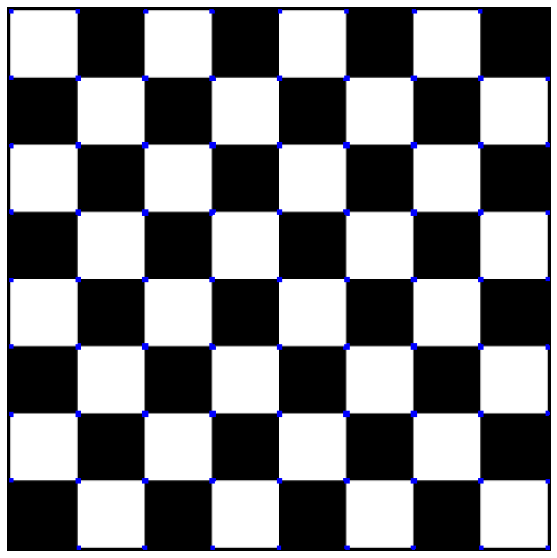

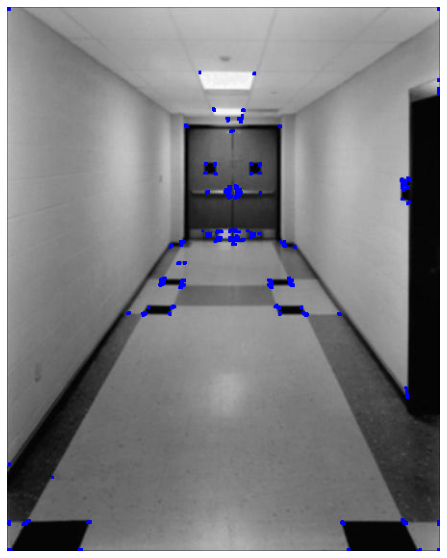

In [ ]:
### TEST THE ALGORITHM ON IMAGES
filenames = ['chessboard.png', 'corridor.jpg']
display_corners(filenames)

# References

<a name="Book"></a>
1. Book
   * [Richard Szeliski (2010), Computer Vision: Algorithms and Applications, 2010 Draft, Springer](http://szeliski.org/Book/drafts/SzeliskiBook_20100903_draft.pdf)
       * Check pages 207 - 234 to understand the foundations and mathematics of feature detection and matching in detail.

2. University Lecture Slides
   
   <a name="Slide1"></a>
   2.1 [Juan Carlos Niebles and Ranjay Krishna, Stanford Vision and Learning Lab, Lecture: RANSAC and feature detectors](http://vision.stanford.edu/teaching/cs131_fall1920/slides/05_ransac.pdf)
    * Check pages 45 - 64 to understand the concept and mathematics of Harris corner detector

   2.2 [Features and Image Matching - Rajesh Rao, University of Washington](https://courses.cs.washington.edu/courses/cse455/09wi/Lects/lect6.pdf)
    * Check pages 1 - 35 to understand the concepts and mathematics of Harris corner detector

3. Tutorial
    <a name="tutorial"></a>
    * [OpenCV Harris Corner Detection Tutorial](https://docs.opencv.org/master/dc/d0d/tutorial_py_features_harris.html)


